In [8]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


class DynamicClusters:

    def __init__(
        self,
        n_classes,
        n_samples_per_class,
        kernel_type='points',
        max_iter=100,
        tol=1e-4
    ):
        """
        Initialisation de la méthode des nuées dynamiques.

        Paramètres :
        - n_classes : nombre de classes (K)
        - n_samples_per_class : nombre d'éléments dans le noyau/étalon
        - kernel_type : type de représentation du noyau
                        ('points', 'axes_factoriels',
                         'distribution', 'centre')
        - max_iter : nombre maximal d'itérations
        - tol : seuil de tolérance pour la convergence
        """

        self.K = n_classes
        self.n_i = n_samples_per_class
        self.kernel_type = kernel_type
        self.max_iter = max_iter
        self.tol = tol

        self.cores = None
        self.labels = None
        self.history_criterion = []


    # ==========================================================
    # CALCUL DES DISTANCES
    # ==========================================================

    def _compute_distance(self, X, cores):
        """
        Calcule la distance entre chaque point de X
        et chaque noyau.
        """

        N = X.shape[0]

        # Matrice des distances :
        # lignes = points
        # colonnes = classes
        distances = np.zeros((N, self.K))

        for i in range(self.K):

            # --------------------------------------------------
            # CAS DU CENTRE : K-MEANS
            # --------------------------------------------------

            if self.kernel_type == 'centre':

                distances[:, i] = np.linalg.norm(
                    X - cores[i],
                    axis=1
                )

            # --------------------------------------------------
            # CAS DES NOYAUX COMPOSES DE PLUSIEURS POINTS
            # --------------------------------------------------

            else:

                core_i = cores[i]

                # Distance entre chaque point X
                # et chaque point du noyau
                dist_to_core = np.linalg.norm(
                    X[:, np.newaxis, :]
                    - core_i[np.newaxis, :, :],
                    axis=2
                )

                # --------------------------------------------------
                # POINTS / DISTRIBUTION
                # Distance moyenne
                # --------------------------------------------------

                if (
                    self.kernel_type == 'points'
                    or self.kernel_type == 'distribution'
                ):

                    distances[:, i] = np.mean(
                        dist_to_core,
                        axis=1
                    )

                # --------------------------------------------------
                # AXES FACTORIELS
                # Distance minimale
                # --------------------------------------------------

                elif self.kernel_type == 'axes_factoriels':

                    distances[:, i] = np.min(
                        dist_to_core,
                        axis=1
                    )

                # --------------------------------------------------
                # AUTRE CAS
                # --------------------------------------------------

                else:

                    distances[:, i] = np.mean(
                        dist_to_core,
                        axis=1
                    )

        return distances


    # ==========================================================
    # MISE À JOUR DES NOYAUX
    # ==========================================================

    def _update_cores(self, X, C_indices):
        """
        Mise à jour des noyaux.

        Pour chaque classe :
        - on récupère les points appartenant à la classe ;
        - on cherche les points les plus représentatifs ;
        - ces points deviennent le nouveau noyau.
        """

        N = X.shape[0]

        new_cores = []

        for i in range(self.K):

            # Sélection des points de la classe i
            class_mask = (C_indices == i)

            class_points = X[class_mask]

            # --------------------------------------------------
            # SI LA CLASSE EST VIDE
            # --------------------------------------------------

            if len(class_points) == 0:

                print(
                    f"Attention : la classe {i} est vide. "
                    f"Nouveau noyau choisi aléatoirement."
                )

                idx = np.random.choice(
                    N,
                    self.n_i,
                    replace=False
                )

                new_cores.append(X[idx])

                continue

            # --------------------------------------------------
            # CAS CENTRE : K-MEANS
            # --------------------------------------------------

            if self.kernel_type == 'centre':

                center = np.mean(
                    class_points,
                    axis=0
                )

                new_cores.append(center)

            # --------------------------------------------------
            # CAS DES NOYAUX COMPOSES DE PLUSIEURS POINTS
            # --------------------------------------------------

            else:

                # Distance entre tous les points
                # et les points de la classe
                all_dist_to_class = np.linalg.norm(
                    X[:, np.newaxis, :]
                    - class_points[np.newaxis, :, :],
                    axis=2
                )

                # Distance moyenne d'un point
                # aux points de la classe
                R_x = np.mean(
                    all_dist_to_class,
                    axis=1
                )

                # Sélection des n_i points les plus représentatifs
                best_indices = np.argsort(R_x)[:self.n_i]

                new_cores.append(
                    X[best_indices]
                )

        return np.array(new_cores)


    # ==========================================================
    # APPRENTISSAGE
    # ==========================================================

    def fit(self, X):
        """
        Exécute l'algorithme itératif des nuées dynamiques.
        """

        N = X.shape[0]

        # --------------------------------------------------
        # INFORMATIONS GÉNÉRALES
        # --------------------------------------------------

        print("\n")
        print("=" * 65)
        print("           MÉTHODE DES NUÉES DYNAMIQUES")
        print("=" * 65)

        print(f"Nombre de données       : {N}")
        print(f"Nombre de classes (K)  : {self.K}")
        print(f"Taille du noyau (n_i)  : {self.n_i}")
        print(f"Type de noyau           : {self.kernel_type}")
        print(f"Nombre max d'itérations : {self.max_iter}")
        print(f"Tolérance               : {self.tol}")

        # --------------------------------------------------
        # INITIALISATION DES NOYAUX
        # --------------------------------------------------

        print("\n")
        print("-" * 65)
        print("INITIALISATION DES NOYAUX")
        print("-" * 65)

        if self.kernel_type == 'centre':

            # K centres choisis aléatoirement
            init_idx = np.random.choice(
                N,
                self.K,
                replace=False
            )

            self.cores = X[init_idx]

        else:

            # Pour chaque classe :
            # sélection de n_i points aléatoires
            self.cores = np.array([
                X[
                    np.random.choice(
                        N,
                        self.n_i,
                        replace=False
                    )
                ]

                for _ in range(self.K)
            ])

        # Affichage des noyaux initiaux
        for i, core in enumerate(self.cores):

            if self.kernel_type == 'centre':

                print(
                    f"Classe {i} → Centre initial : {core}"
                )

            else:

                print(
                    f"Classe {i} → "
                    f"{len(core)} points dans le noyau"
                )

        # --------------------------------------------------
        # BOUCLE PRINCIPALE
        # --------------------------------------------------

        for iteration in range(self.max_iter):

            print("\n")
            print(
                f"================ ITÉRATION "
                f"{iteration + 1} ================"
            )

            # --------------------------------------------------
            # ÉTAPE 1 : CALCUL DES DISTANCES
            # --------------------------------------------------

            distances = self._compute_distance(
                X,
                self.cores
            )

            # --------------------------------------------------
            # ÉTAPE 2 : AFFECTATION DES POINTS
            # --------------------------------------------------

            C_indices = np.argmin(
                distances,
                axis=1
            )

            # --------------------------------------------------
            # ÉTAPE 3 : CALCUL DU CRITÈRE
            # --------------------------------------------------

            current_S = np.sum(
                np.min(distances, axis=1) ** 2
            )

            self.history_criterion.append(
                current_S
            )

            print(
                f"Critère S = {current_S:.6f}"
            )

            # --------------------------------------------------
            # NOMBRE DE POINTS PAR CLASSE
            # --------------------------------------------------

            print("\nRépartition des points :")

            for k in range(self.K):

                nb_points = np.sum(
                    C_indices == k
                )

                pourcentage = (
                    nb_points / N
                ) * 100

                print(
                    f"  Classe {k} : "
                    f"{nb_points} points "
                    f"({pourcentage:.2f} %)"
                )

            # --------------------------------------------------
            # TEST DE CONVERGENCE DU CRITÈRE
            # --------------------------------------------------

            if iteration > 0:

                rel_change = abs(
                    1
                    - (
                        self.history_criterion[-1]
                        /
                        self.history_criterion[-2]
                    )
                )

                print(
                    f"\nVariation relative : "
                    f"{rel_change:.8f}"
                )

                if rel_change < self.tol:

                    print("\n")
                    print(
                        ">>> CONVERGENCE ATTEINTE <<<"
                    )

                    print(
                        f"Nombre d'itérations : "
                        f"{iteration + 1}"
                    )

                    break

            # --------------------------------------------------
            # SAUVEGARDE DES ANCIENS NOYAUX
            # --------------------------------------------------

            old_cores = self.cores.copy()

            # --------------------------------------------------
            # ÉTAPE 4 : MISE À JOUR DES NOYAUX
            # --------------------------------------------------

            self.cores = self._update_cores(
                X,
                C_indices
            )

            # --------------------------------------------------
            # TEST DE STABILITÉ DES NOYAUX
            # --------------------------------------------------

            if np.allclose(
                old_cores,
                self.cores,
                atol=1e-5
            ):

                print("\n")
                print(
                    ">>> STABILITÉ DES NOYAUX ATTEINTE <<<"
                )

                print(
                    f"Nombre d'itérations : "
                    f"{iteration + 1}"
                )

                break

        # --------------------------------------------------
        # SAUVEGARDE DES LABELS
        # --------------------------------------------------

        self.labels = C_indices

        # ==================================================
        # RÉSULTATS FINAUX
        # ==================================================

        print("\n")
        print("=" * 65)
        print("                    RÉSULTATS FINAUX")
        print("=" * 65)

        print(
            f"\nNombre d'itérations effectuées : "
            f"{iteration + 1}"
        )

        print(
            f"Critère final S                : "
            f"{current_S:.6f}"
        )

        # --------------------------------------------------
        # RÉPARTITION FINALE
        # --------------------------------------------------

        print("\nRépartition finale des données :")

        for k in range(self.K):

            nb_points = np.sum(
                self.labels == k
            )

            pourcentage = (
                nb_points / N
            ) * 100

            print(
                f"  Classe {k} : "
                f"{nb_points} points "
                f"({pourcentage:.2f} %)"
            )

        # --------------------------------------------------
        # AFFICHAGE DES NOYAUX FINAUX
        # --------------------------------------------------

        print("\nNoyaux finaux :")

        for i, core in enumerate(self.cores):

            print(f"\nClasse {i} :")

            if self.kernel_type == 'centre':

                print(
                    f"  Centre = {core}"
                )

            else:

                print(
                    f"  Nombre de points = {len(core)}"
                )

                for j, point in enumerate(core):

                    print(
                        f"    Point {j + 1} : "
                        f"{point}"
                    )

        # --------------------------------------------------
        # PREMIERS LABELS
        # --------------------------------------------------

        print("\nClasses des 20 premiers points :")

        print(
            self.labels[:20]
        )

        print("\n" + "=" * 65)

        return self.labels


# ==========================================================
# SCRIPT DE TEST
# ==========================================================

print("\n")
print("=" * 65)
print("              GÉNÉRATION DES DONNÉES")
print("=" * 65)

# Génération de 300 données artificielles
# réparties autour de 3 centres

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

print(
    f"\nNombre de points générés : {X.shape[0]}"
)

print(
    f"Nombre de dimensions      : {X.shape[1]}"
)

print(
    f"Forme de X                : {X.shape}"
)


# ==========================================================
# LANCEMENT DE L'ALGORITHME
# ==========================================================

print("\n")
print("=" * 65)
print("             LANCEMENT DE L'ALGORITHME")
print("=" * 65)

# Création de l'objet Nuées Dynamiques

nuées = DynamicClusters(
    n_classes=3,
    n_samples_per_class=10,
    kernel_type='points',
    max_iter=50,
    tol=1e-4
)

# Exécution

labels = nuées.fit(X)


# ==========================================================
# ANALYSE DES RÉSULTATS
# ==========================================================

print("\n")
print("=" * 65)
print("                 ANALYSE DES RÉSULTATS")
print("=" * 65)

print("\nClasses attribuées aux 20 premiers points :")

print(labels[:20])

print("\nNombre de points dans chaque classe :")

for k in range(3):

    nb_points = np.sum(
        labels == k
    )

    print(
        f"  Classe {k} : "
        f"{nb_points} points"
    )








              GÉNÉRATION DES DONNÉES

Nombre de points générés : 300
Nombre de dimensions      : 2
Forme de X                : (300, 2)


             LANCEMENT DE L'ALGORITHME


           MÉTHODE DES NUÉES DYNAMIQUES
Nombre de données       : 300
Nombre de classes (K)  : 3
Taille du noyau (n_i)  : 10
Type de noyau           : points
Nombre max d'itérations : 50
Tolérance               : 0.0001


-----------------------------------------------------------------
INITIALISATION DES NOYAUX
-----------------------------------------------------------------
Classe 0 → 10 points dans le noyau
Classe 1 → 10 points dans le noyau
Classe 2 → 10 points dans le noyau


================ ITÉRATION 1 ================
Critère S = 26283.097069

Répartition des points :
  Classe 0 : 161 points (53.67 %)
  Classe 1 : 39 points (13.00 %)
  Classe 2 : 100 points (33.33 %)


================ ITÉRATION 2 ================
Critère S = 368.279464

Répartition des points :
  Classe 0 : 100 points (33.33 %)
  C

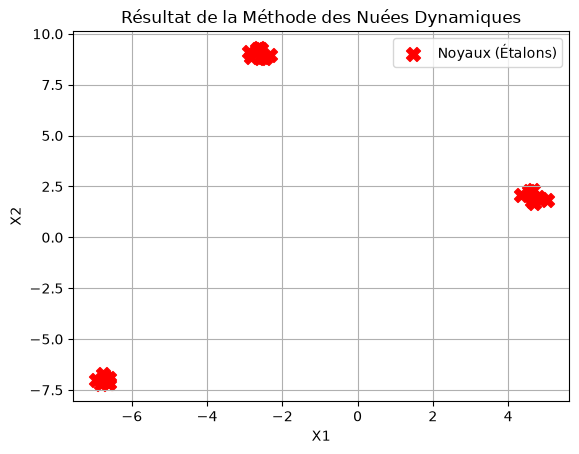

In [6]:
# ----------------------------------------------------------
# AFFICHAGE DES NOYAUX
# ----------------------------------------------------------

if (
    hasattr(nuées, 'cores')
    and nuées.cores is not None
):

    for i, core in enumerate(nuées.cores):

        # Si le noyau contient plusieurs points
        if len(core.shape) > 1:

            plt.scatter(
                core[:, 0],
                core[:, 1],
                color='red',
                marker='X',
                s=100,
                label=(
                    'Noyaux (Étalons)'
                    if i == 0
                    else ""
                )
            )

        # Si le noyau est un centre
        else:

            plt.scatter(
                core[0],
                core[1],
                color='red',
                marker='X',
                s=150,
                label=(
                    'Centres'
                    if i == 0
                    else ""
                )
            )


# ----------------------------------------------------------
# TITRE ET AXES
# ----------------------------------------------------------

plt.title(
    "Résultat de la Méthode des Nuées Dynamiques"
)

plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()
plt.grid(True)

plt.show()




                AFFICHAGE DU GRAPHIQUE


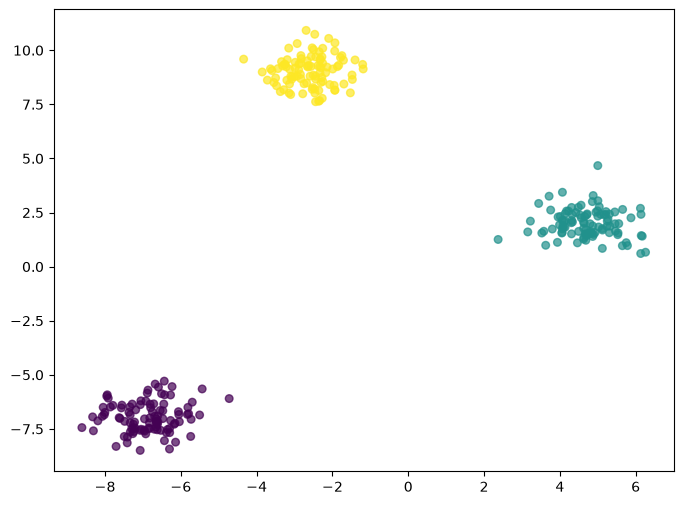

In [7]:
# ==========================================================
# AFFICHAGE DU GRAPHIQUE
# ==========================================================

print("\n")
print("=" * 65)
print("                AFFICHAGE DU GRAPHIQUE")
print("=" * 65)

plt.figure(
    figsize=(8, 6)
)

# Affichage des données
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=30,
    alpha=0.7,
    label='Points'
)

